In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Display numbers with commas
pd.options.display.float_format = '{:,.2f}'.format

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
#Load Dataset

df = pd.read_csv("bank-full.csv", sep=';')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
#Dataset Shape

print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 45211
Number of columns : 17


In [4]:
#First Five Records
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
#Last Five Records
df.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [6]:
#Random Sample

df.sample(10, random_state=42)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no
30813,28,blue-collar,married,secondary,no,1134,no,no,cellular,9,feb,130,3,-1,0,unknown,no
35463,24,management,single,tertiary,no,1085,no,yes,cellular,7,may,95,6,-1,0,unknown,no
31382,37,admin.,single,secondary,no,127,no,no,cellular,23,mar,83,4,-1,0,unknown,no
16904,30,blue-collar,single,secondary,no,3,yes,no,cellular,25,jul,51,1,-1,0,unknown,no
11930,38,technician,single,secondary,no,258,no,yes,unknown,20,jun,587,2,-1,0,unknown,no


In [7]:
#Dataset Understanding

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
#Data Types

df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [9]:
#Missing Values

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_df

,Column,Missing Values
0,age,0
1,job,0
2,marital,0
3,education,0
4,default,0
5,balance,0
6,housing,0
7,loan,0
8,contact,0
9,day,0


In [10]:
#Missing Value Percentage

missing_percent = (df.isnull().sum()/len(df))*100


missing_percent = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_percent

,Column,Missing Values
0,age,0
1,job,0
2,marital,0
3,education,0
4,default,0
5,balance,0
6,housing,0
7,loan,0
8,contact,0
9,day,0


In [11]:
#Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate Records: ", duplicates)

Duplicate Records:  0


In [12]:
#Statistical Summary (Numerical Features)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"45,211.00",40.94,10.62,18.00,33.00,39.00,48.00,95.00
balance,"45,211.00","1,362.27","3,044.77","-8,019.00",72.00,448.00,"1,428.00","102,127.00"
day,"45,211.00",15.81,8.32,1.00,8.00,16.00,21.00,31.00
duration,"45,211.00",258.16,257.53,0.00,103.00,180.00,319.00,"4,918.00"
campaign,"45,211.00",2.76,3.10,1.00,1.00,2.00,3.00,63.00
pdays,"45,211.00",40.20,100.13,-1.00,-1.00,-1.00,-1.00,871.00
previous,"45,211.00",0.58,2.30,0.00,0.00,0.00,0.00,275.00


In [13]:
#Numerical Columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns")

print("-"*40)

print(numerical_columns)

Numerical Columns
----------------------------------------
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [14]:
#Categorical Columns

categorical_columns = df.select_dtypes(include='object').columns

print("Categoricl Columns")

print("-"*40)

print(categorical_columns)

Categoricl Columns
----------------------------------------
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [15]:
#Unique Values in Every Column

for col in df.columns:
  print(f"{col} :  {df[col].nunique()} unique values")

age :  77 unique values
job :  12 unique values
marital :  3 unique values
education :  4 unique values
default :  2 unique values
balance :  7168 unique values
housing :  2 unique values
loan :  2 unique values
contact :  3 unique values
day :  31 unique values
month :  12 unique values
duration :  1573 unique values
campaign :  48 unique values
pdays :  559 unique values
previous :  41 unique values
poutcome :  4 unique values
y :  2 unique values


In [16]:
#Target Variable Analysis
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [17]:
#Purchase Percentage

purchase_percentage = df['y'].value_counts(normalize=True)*100

purchase_percentage

,proportion
y,
no,88.30
yes,11.70


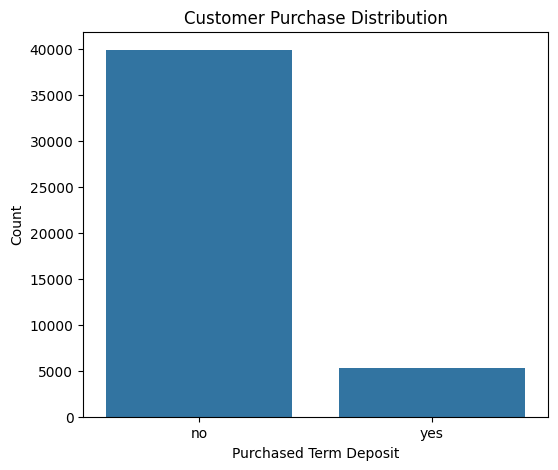

In [18]:
#Target Distribution Chart

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='y')

plt.title("Customer Purchase Distribution")

plt.xlabel("Purchased Term Deposit")

plt.ylabel("Count")

plt.show()

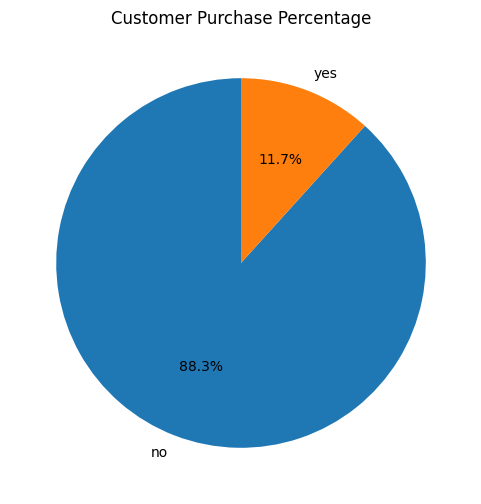

In [19]:
#Purchase Percentage Chart

df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    startangle=90
)

plt.ylabel("")

plt.title("Customer Purchase Percentage")

plt.show()

In [20]:
#Class Imbalance check

purchase = df['y'].value_counts()

print(purchase)

ratio = purchase['no'] / purchase['yes']

print(f"\nImbalance Ratio : {ratio:.2f} : 1")

y
no     39922
yes     5289
Name: count, dtype: int64

Imbalance Ratio : 7.55 : 1


In [21]:
#Initial Business Insights

# ==========================================
# Initial Business Insights
# ==========================================

print("="*60)
print("INITIAL BUSINESS INSIGHTS")
print("="*60)


print(f"\n Total Customers : {len(df)}")

print(f"Customers Purchased : {(df['y']=='yes').sum()}")

print(f"Customers Didn't Purchase : {(df['y']=='no').sum()}")

purchase_rate = (df['y']=='yes').mean()*100

print(f"\nOverall Purchase Rate : {purchase_rate:.2f}%")

print(f"Overall Non-Purchase Rate : {100-purchase_rate:.2f}%")

print("\nObservation:")

if purchase_rate < 20:
    print("- The dataset is highly imbalanced.")
    print("- Most customers did not subscribe to the term deposit.")
    print("- Data balancing techniques may improve model performance.")
else:
    print("- The classes are relatively balanced.")

INITIAL BUSINESS INSIGHTS

 Total Customers : 45211
Customers Purchased : 5289
Customers Didn't Purchase : 39922

Overall Purchase Rate : 11.70%
Overall Non-Purchase Rate : 88.30%

Observation:
- The dataset is highly imbalanced.
- Most customers did not subscribe to the term deposit.
- Data balancing techniques may improve model performance.


In [22]:
#Data Cleaning & Preprocessing

print("Dataset Shape :", df.shape)

Dataset Shape : (45211, 17)


In [23]:
#Missing Values

missing = df.isnull().sum()

missing = missing[missing>0]

if len(missing) == 0:
    print("No Missing Values Found.")
else:
    print(missing)

No Missing Values Found.


In [24]:
#Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [25]:
#Remove Duplicate Records

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully.")

print("New Dataset Shape :", df.shape)

Duplicates Removed Successfully.
New Dataset Shape : (45211, 17)


In [26]:
#Check "Unknown" Values

# ==========================================
# Unknown Values
# ==========================================

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

  unknown_count = (df[col] == 'unknown').sum()

  if unknown_count > 0:
    print(f"{col} : {unknown_count}")

job : 288
education : 1857
contact : 13020
poutcome : 36959


In [27]:
#Percentage of Unknown Values

for col in categorical_columns:

  unknown = (df[col] == 'unknown').sum()

  percentage = unknown / len(df)*100

  if unknown > 0:

    print(f"{col}")

    print(f"Unknown Values : {unknown}")

    print(f"Percentage : {percentage:.2f}%")

    print("-"*40)

job
Unknown Values : 288
Percentage : 0.64%
----------------------------------------
education
Unknown Values : 1857
Percentage : 4.11%
----------------------------------------
contact
Unknown Values : 13020
Percentage : 28.80%
----------------------------------------
poutcome
Unknown Values : 36959
Percentage : 81.75%
----------------------------------------


In [28]:
#Replace Unknown with Mode

for col in categorical_columns:

  if "unknown" in df[col].values:

    mode = df.loc[df[col] != 'unknown', col].mode()[0]

    df[col] = df[col].replace("unknown", mode)


print("Unknown Values Replaced Successfully.")




Unknown Values Replaced Successfully.


In [29]:
#Verify Unknown Values

for col in categorical_columns:

  print(f"{col} : ", (df[col] == 'Unknown').sum())

job :  0
marital :  0
education :  0
default :  0
housing :  0
loan :  0
contact :  0
month :  0
poutcome :  0
y :  0


In [30]:
#Exploratory Cleaning

#Numerical Columns

numerical_columns = df.select_dtypes(include='number').columns

numerical_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

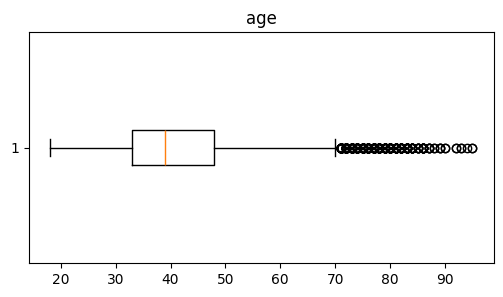

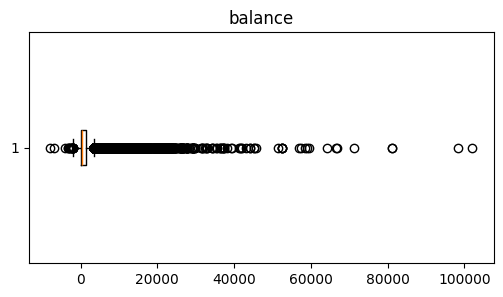

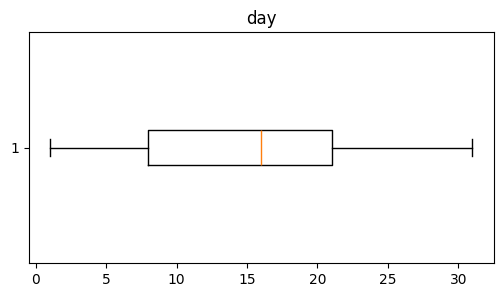

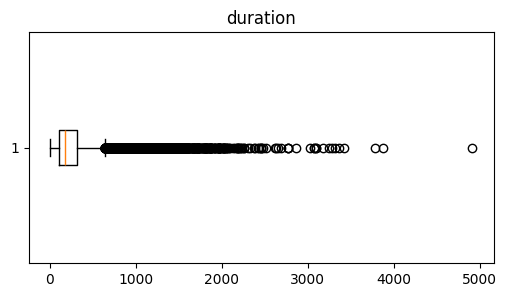

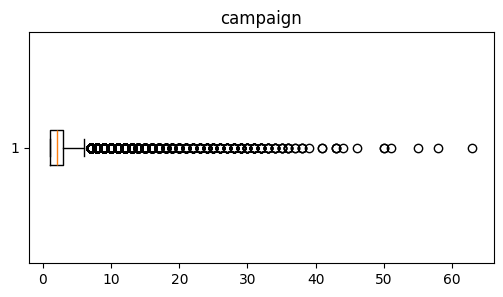

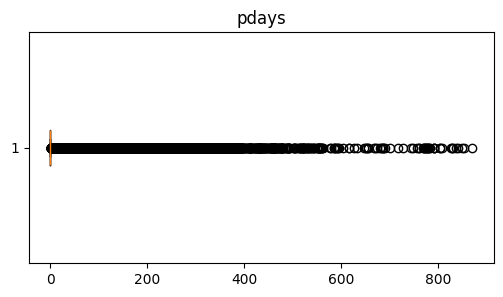

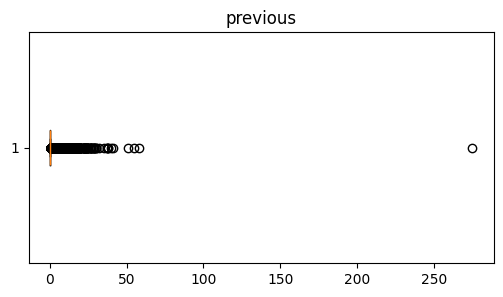

In [31]:
#Boxplots (Outlier Detection)

import matplotlib.pyplot as plt

for col in numerical_columns:

 plt.figure(figsize=(6,3))

 plt.boxplot(df[col], vert=False)

 plt.title(col)

 plt.show()


In [32]:
#IQR Outlier Count

for col in numerical_columns:

  Q1 = df[col].quantile(0.25)

  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5*IQR

  upper_bound = Q3 + 1.5*IQR

  outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  print(f"{col} : {len(outlier)} outliers")

age : 487 outliers
balance : 4729 outliers
day : 0 outliers
duration : 3235 outliers
campaign : 3064 outliers
pdays : 8257 outliers
previous : 8257 outliers


In [33]:
#Feature Engineering

#Encode Target Variable

df['y'] = df['y'].map({
    'yes': 1,
    'no':0



})

df['y'].head()

,y
0,0
1,0
2,0
3,0
4,0


In [34]:
#Separate Features and Target

X = df.drop('y', axis=1)

y = df['y']

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (45211, 16)
Target Shape : (45211,)


In [35]:
#One-Hot Encoding

x = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Shape :", X.shape)

Encoded Shape : (45211, 16)


In [36]:
#Feature Names

X.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    x,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (36168, 38)
Testing Features : (9043, 38)
Training Target : (36168,)
Testing Target : (9043,)


In [38]:
#Class Distribution

print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

y
0   0.88
1   0.12
Name: proportion, dtype: float64

y
0   0.88
1   0.12
Name: proportion, dtype: float64


In [39]:
#Part 5 – Feature Scaling

#Although Decision Trees don't require scaling, we'll prepare scaled data for later model comparisons.

In [40]:
# ==========================================
# Standard Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully.")

Scaling Completed Successfully.


In [41]:
#Convert Back to DataFrame

X_train_scaled = pd.DataFrame(

     X_train_scaled,

    columns=X_train.columns,

    index=X_train.index
)


X_test_scaled = pd.DataFrame(

    X_test_scaled,

    columns=X_test.columns,

    index=X_test.index

)

X_train_scaled.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
24001,-0.46,-0.16,1.58,-0.46,-0.25,-0.41,-0.24,-0.54,-0.18,-0.17,-0.51,-0.23,-0.19,-0.32,-0.15,2.23,-0.17,-1.23,-0.63,0.90,-0.64,-0.13,-1.12,-0.44,3.82,2.50,-0.07,-0.25,-0.18,-0.43,-0.36,-0.10,-0.66,-0.31,-0.13,-0.11,-0.21,-0.19
43409,-1.59,0.90,-1.30,2.50,0.40,1.45,2.66,-0.54,-0.18,-0.17,-0.51,-0.23,-0.19,-0.32,6.83,-0.45,-0.17,-1.23,1.59,0.90,-0.64,-0.13,-1.12,-0.44,-0.26,-0.40,-0.07,-0.25,-0.18,-0.43,-0.36,-0.10,-0.66,-0.31,-0.13,-0.11,-0.21,-0.19
20669,0.29,-0.37,-0.46,5.70,0.40,-0.41,-0.24,-0.54,-0.18,-0.17,-0.51,-0.23,-0.19,-0.32,-0.15,2.23,-0.17,-1.23,1.59,0.90,-0.64,-0.13,0.89,-0.44,-0.26,2.50,-0.07,-0.25,-0.18,-0.43,-0.36,-0.10,-0.66,-0.31,-0.13,-0.11,-0.21,-0.19
18810,0.67,-0.45,1.82,-0.86,2.65,-0.41,-0.24,-0.54,-0.18,-0.17,-0.51,-0.23,-0.19,-0.32,-0.15,-0.45,5.86,0.81,-0.63,0.90,-0.64,-0.13,-1.12,-0.44,3.82,-0.40,-0.07,-0.25,-0.18,2.35,-0.36,-0.10,-0.66,-0.31,-0.13,-0.11,-0.21,-0.19
23130,-0.27,-0.36,1.22,-0.78,2.33,-0.41,-0.24,-0.54,-0.18,-0.17,-0.51,-0.23,-0.19,-0.32,-0.15,2.23,-0.17,0.81,-0.63,0.90,-0.64,-0.13,-1.12,-0.44,-0.26,2.50,-0.07,-0.25,-0.18,-0.43,-0.36,-0.10,-0.66,-0.31,-0.13,-0.11,-0.21,-0.19


In [42]:
#Final Dataset Summary

# ==========================================
# Final Summary
# ==========================================

print("="*50)

print("DAY 2 SUMMARY")

print("="*50)

print(f"Original Dataset Shape : {df.shape}")

print(f"Training Data : {X_train.shape}")

print(f"Testing Data : {X_test.shape}")

print(f"Total Features After Encoding : {X.shape[1]}")

print(f"Target Classes : {y.unique()}")

print("\nData Cleaning Completed Successfully!")

print("Data Preprocessing Completed Successfully!")

print("Dataset is Ready for Machine Learning!")

DAY 2 SUMMARY
Original Dataset Shape : (45211, 17)
Training Data : (36168, 38)
Testing Data : (9043, 38)
Total Features After Encoding : 16
Target Classes : [0 1]

Data Cleaning Completed Successfully!
Data Preprocessing Completed Successfully!
Dataset is Ready for Machine Learning!


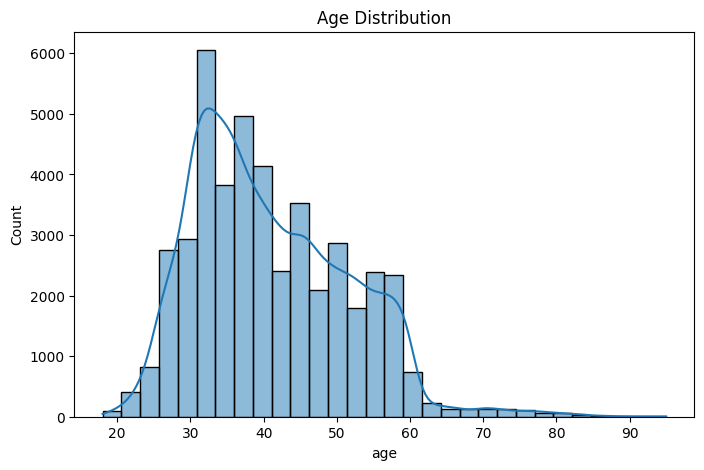

In [43]:
# Exploratory Data Analysis (EDA)

#Univariate Analysis

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

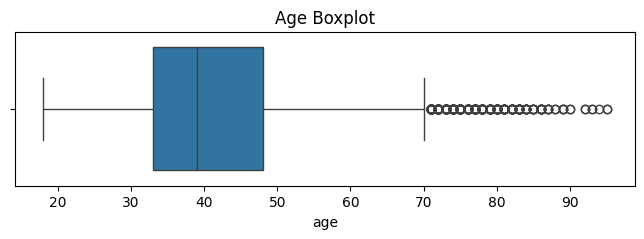

In [44]:
#Age Boxplot

plt.figure(figsize=(8,2))

sns.boxplot(x=df['age'])

plt.title("Age Boxplot")

plt.show()

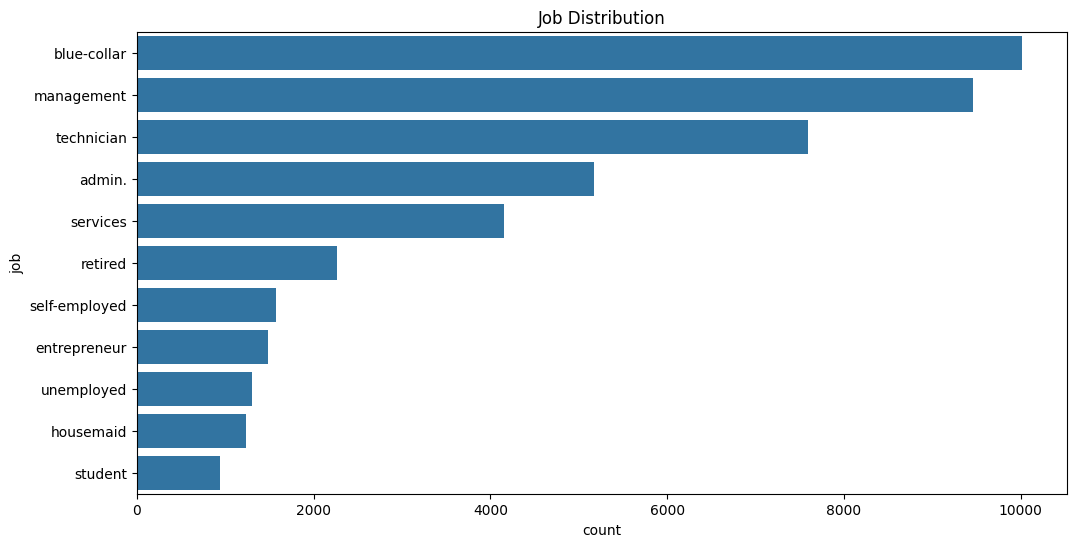

In [45]:
#Job Distribution

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='job',
    order=df['job'].value_counts().index
)

plt.title("Job Distribution")

plt.show()

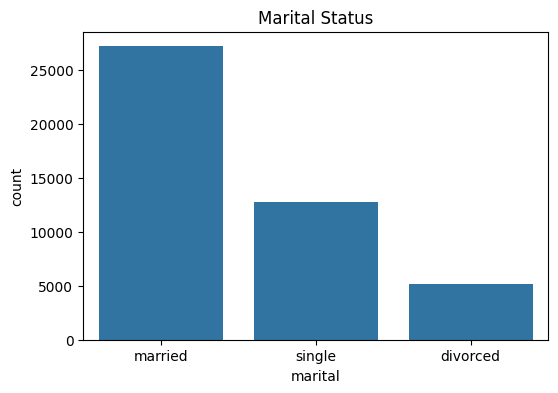

In [46]:
#Marital Status

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='marital'
)

plt.title("Marital Status")

plt.show()

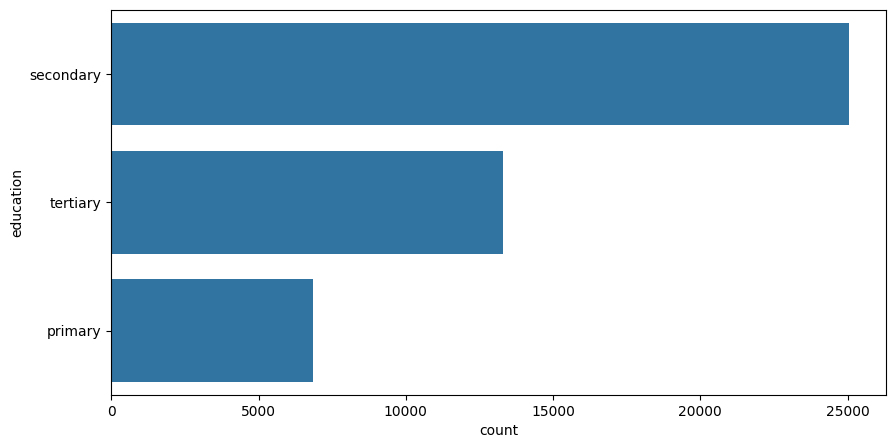

In [47]:
#Education

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='education',
    order=df['education'].value_counts().index
)

plt.show()

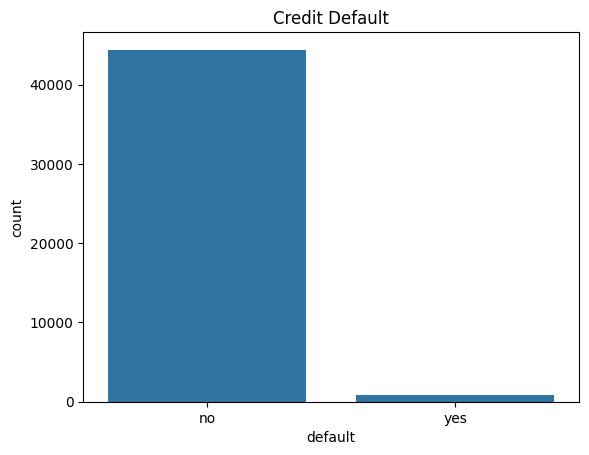

In [48]:
#Default

sns.countplot(data=df,x='default')

plt.title("Credit Default")

plt.show()

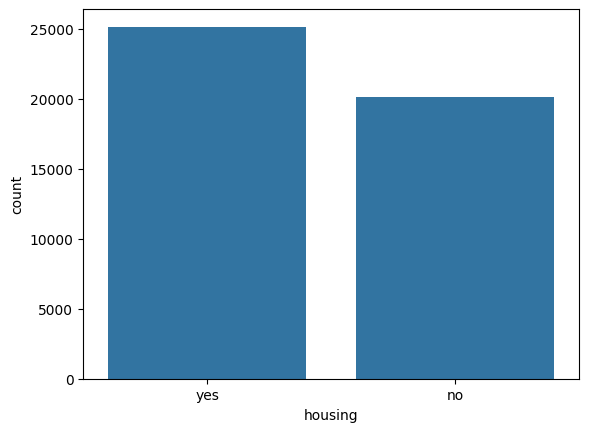

In [49]:
#Housing Loan

sns.countplot(data=df,x='housing')

plt.show()

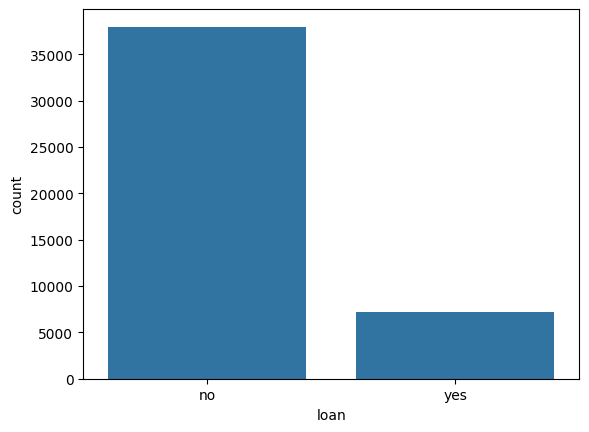

In [50]:
#Personal Loan
sns.countplot(data=df,x='loan')

plt.show()

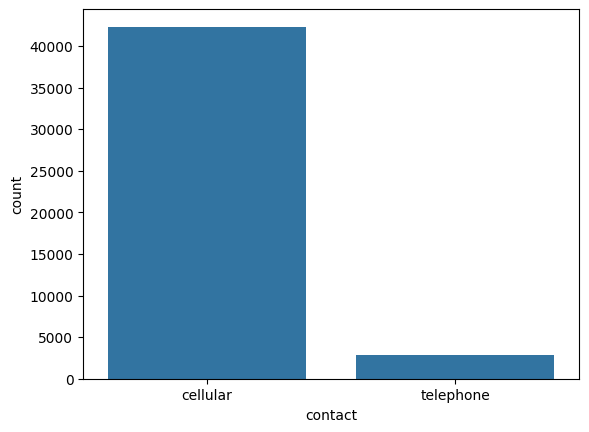

In [51]:
#Contact Method

sns.countplot(data=df,x='contact')

plt.show()

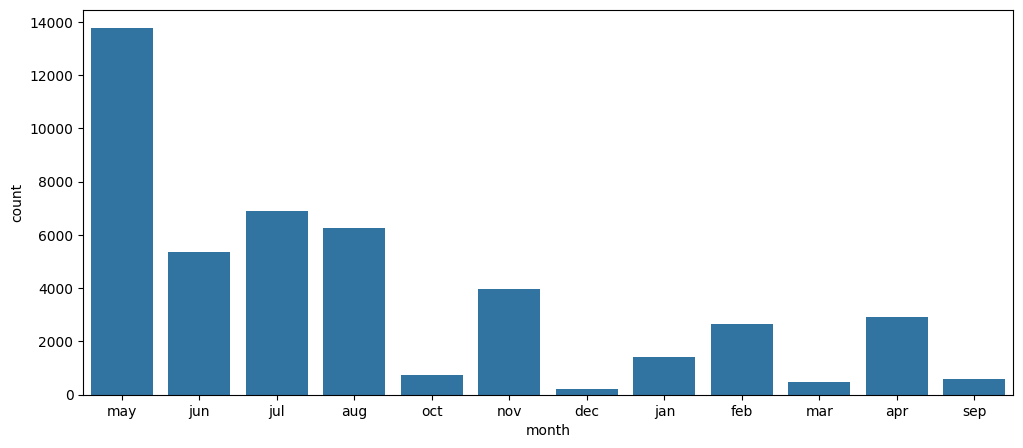

In [52]:
#Month Distribution

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='month'
)

plt.show()

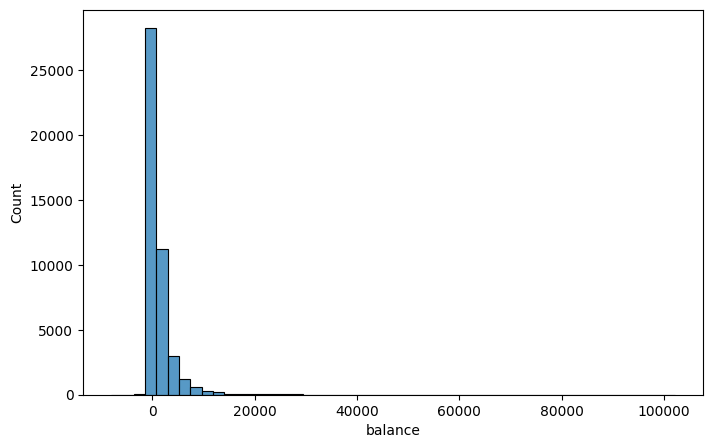

In [53]:
#Numerical Analysis

plt.figure(figsize=(8,5))

sns.histplot(df['balance'], bins=50)

plt.show()

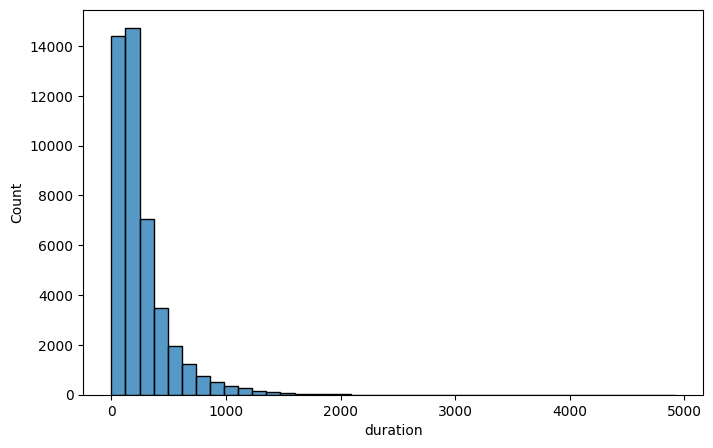

In [54]:
#Duration Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['duration'], bins=40)

plt.show()

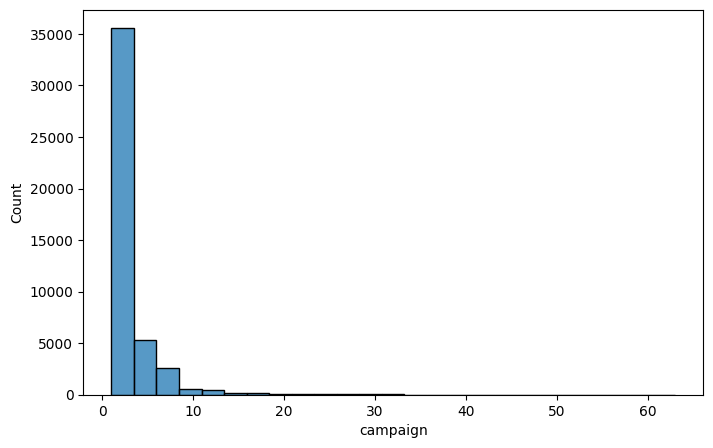

In [55]:
#Campaign Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['campaign'], bins=25)

plt.show()

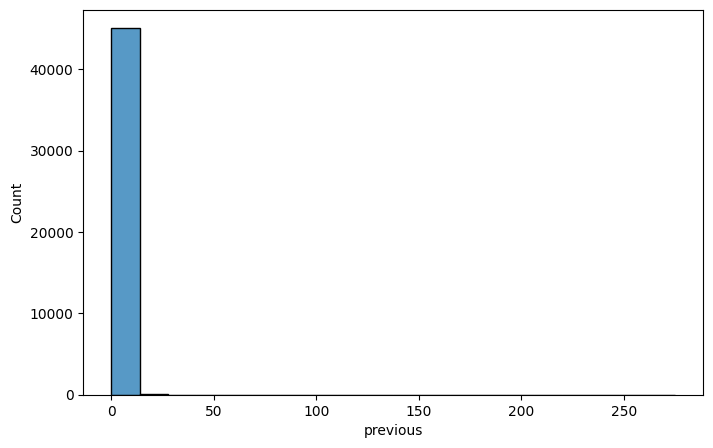

In [56]:
#Previous Contacts

plt.figure(figsize=(8,5))

sns.histplot(df['previous'], bins=20)

plt.show()

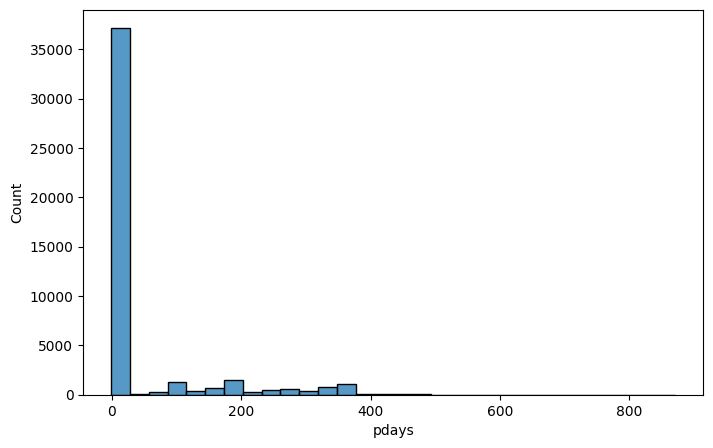

In [57]:
#pdays Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['pdays'], bins=30)

plt.show()

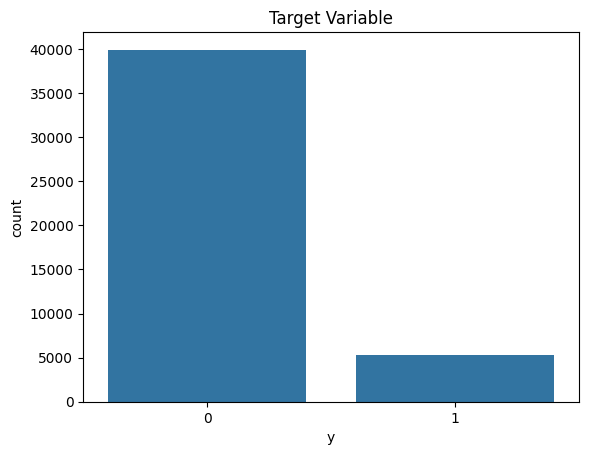

In [58]:
#Target Analysis

#Purchase Distribution

sns.countplot(data=df,x='y')

plt.title("Target Variable")

plt.show()

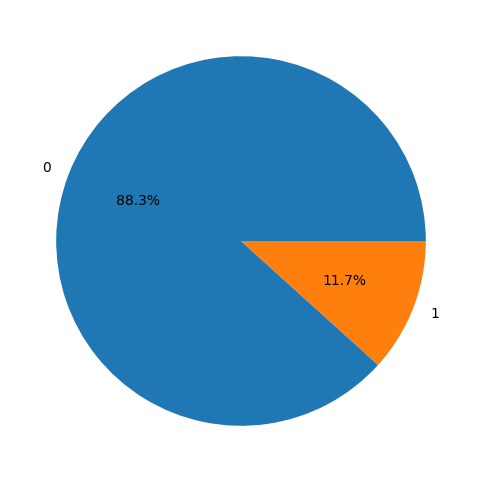

In [59]:
#Purchase Percentage

df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")

plt.show()

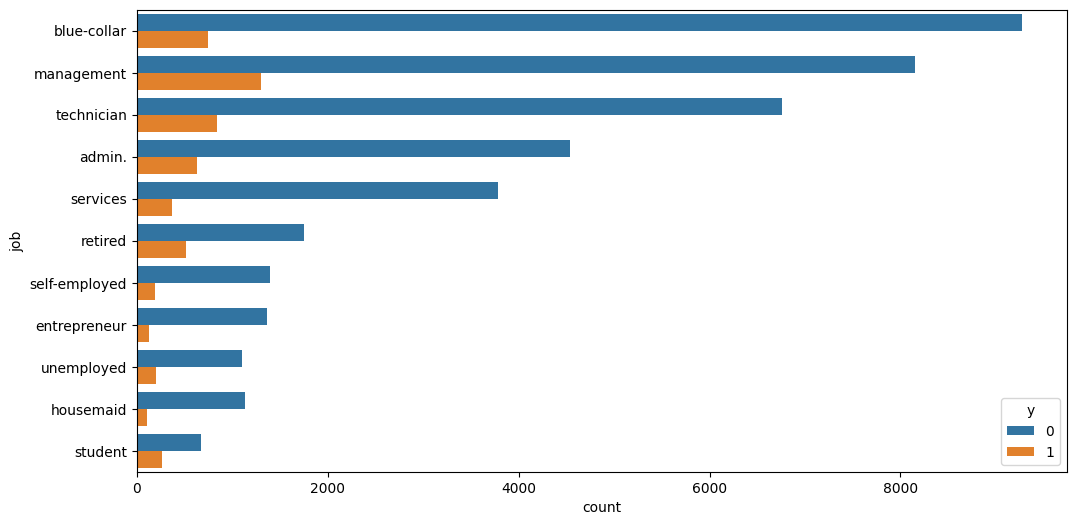

In [60]:
#Relationship Analysis

#Purchase by Job

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='job',
    hue='y',
    order=df['job'].value_counts().index
)

plt.show()

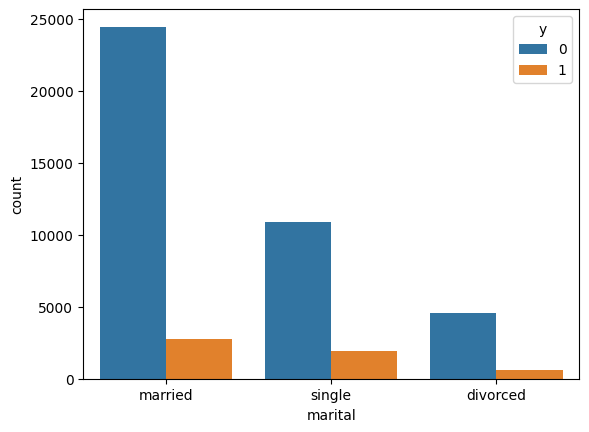

In [61]:
#Purchase by Marital Status

sns.countplot(
    data=df,
    x='marital',
    hue='y'
)

plt.show()

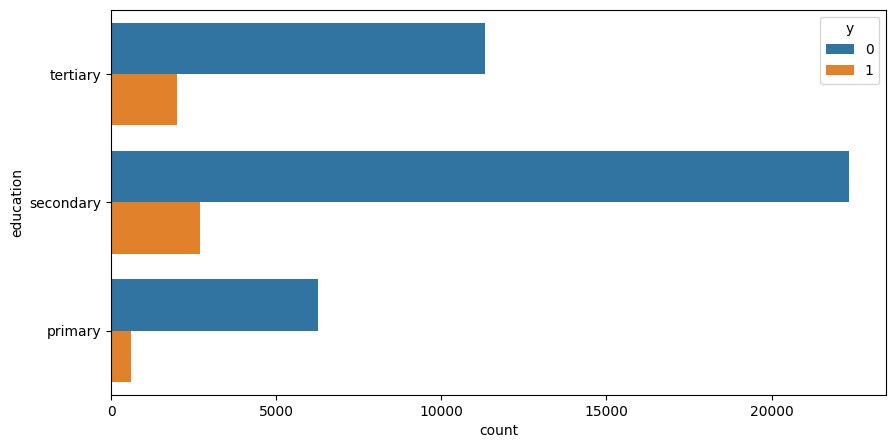

In [62]:
#Purchase by Education

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='education',
    hue='y'
)

plt.show()

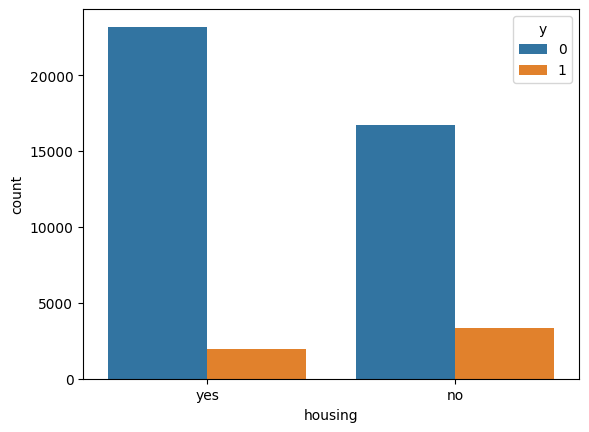

In [63]:
#Purchase by Housing Loan

sns.countplot(
    data=df,
    x='housing',
    hue='y'
)

plt.show()

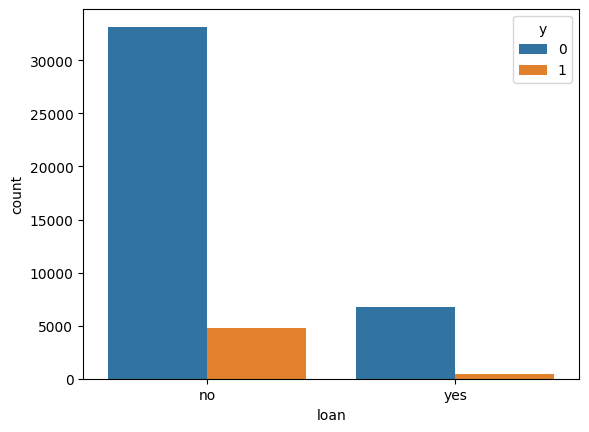

In [64]:
#Purchase by Personal Loan

sns.countplot(
    data=df,
    x='loan',
    hue='y'
)

plt.show()

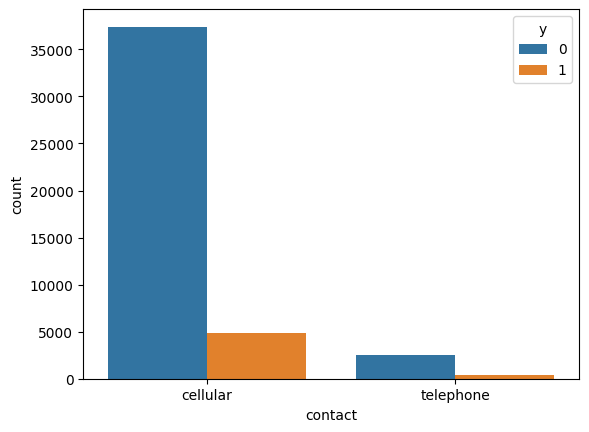

In [65]:
#Purchase by Contact Method

sns.countplot(
    data=df,
    x='contact',
    hue='y'
)

plt.show()

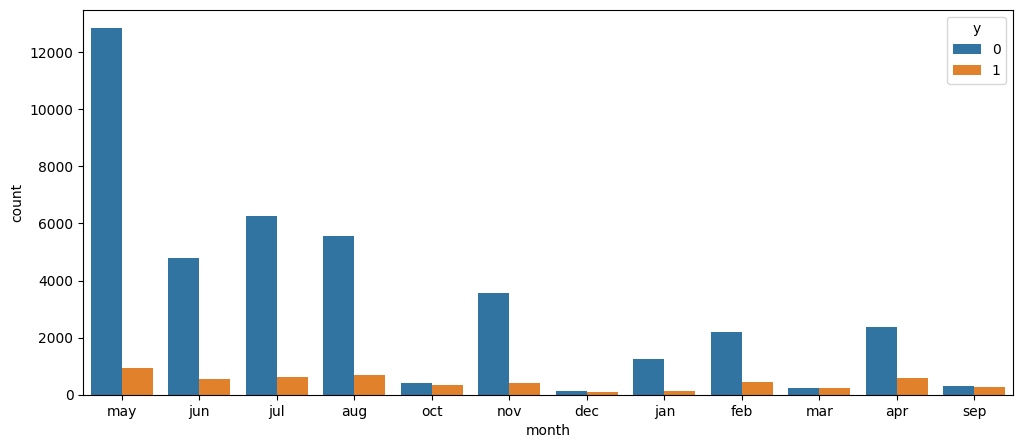

In [66]:
#Purchase by Month

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='month',
    hue='y'
)

plt.show()

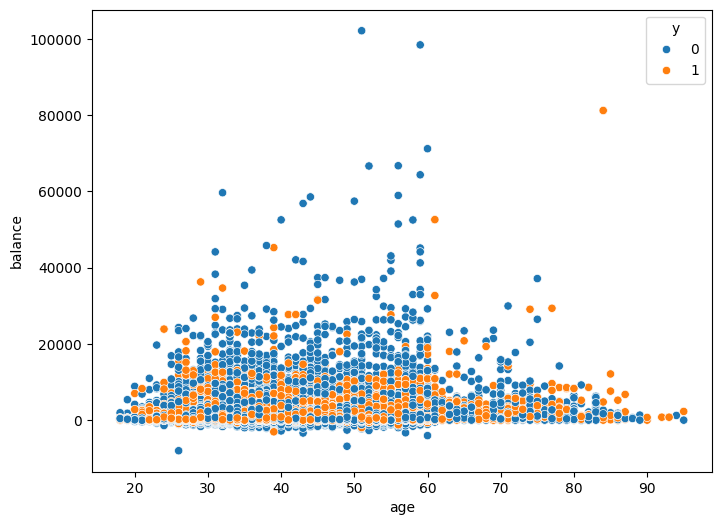

In [67]:
#Numerical Relationships

#Age vs Balance

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='balance',
    hue='y'
)

plt.show()



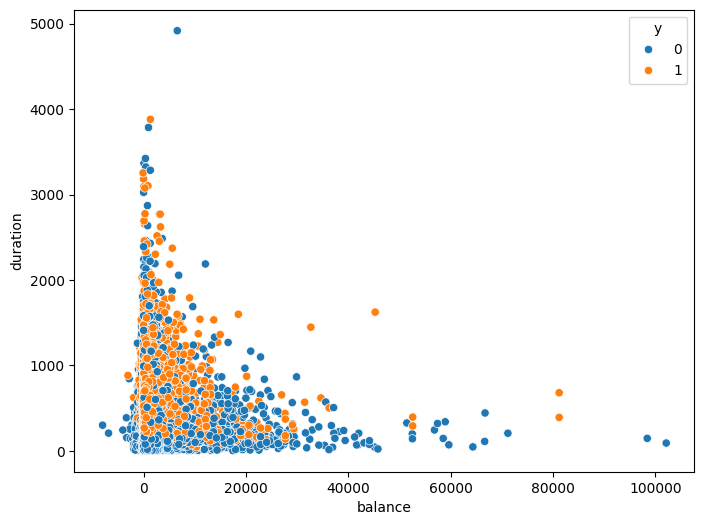

In [68]:
#Balance vs Duration

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='balance',
    y='duration',
    hue='y'
)

plt.show()

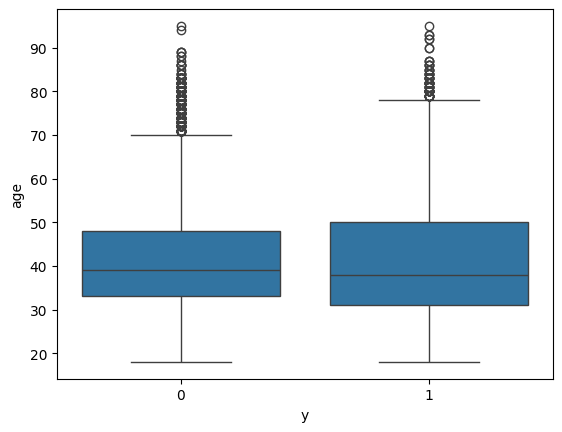

In [69]:
#Boxplot Age vs Purchase

sns.boxplot(
    data=df,
    x='y',
    y='age'
)

plt.show()

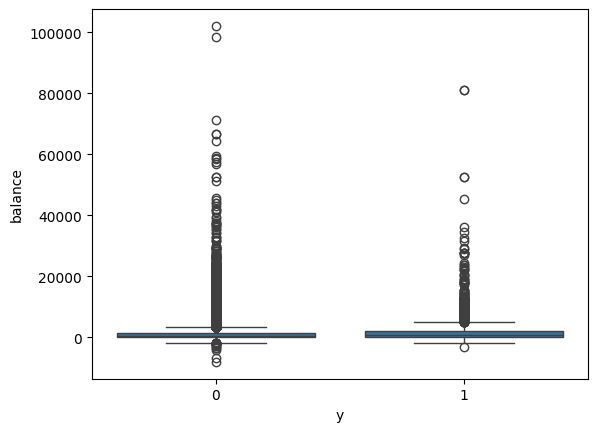

In [70]:
#Boxplot Balance vs Purchase

sns.boxplot(
    data=df,
    x='y',
    y='balance'
)

plt.show()

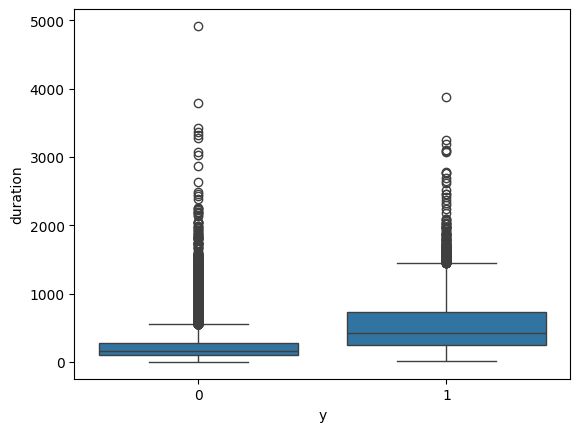

In [71]:
#Boxplot Duration vs Purchase

sns.boxplot(
    data=df,
    x='y',
    y='duration'
)

plt.show()

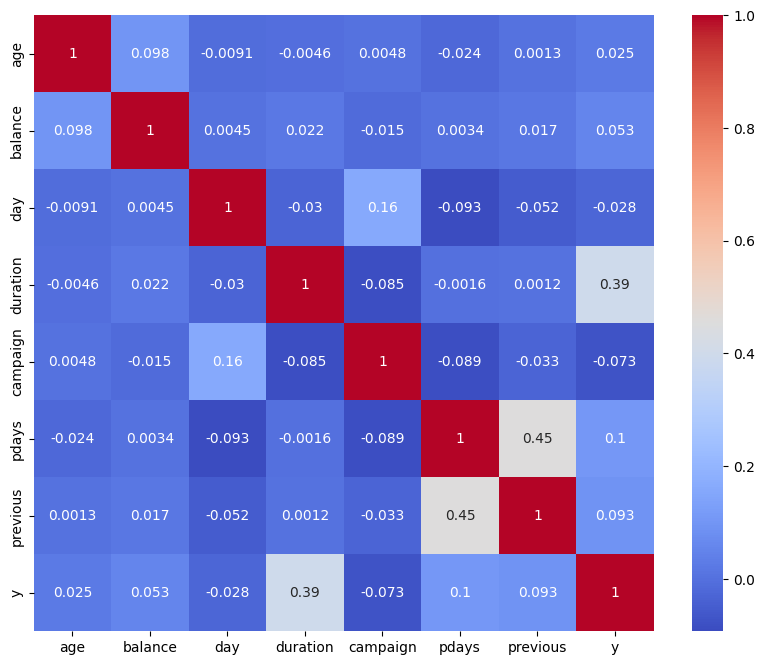

In [72]:
#Correlation Analysis

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

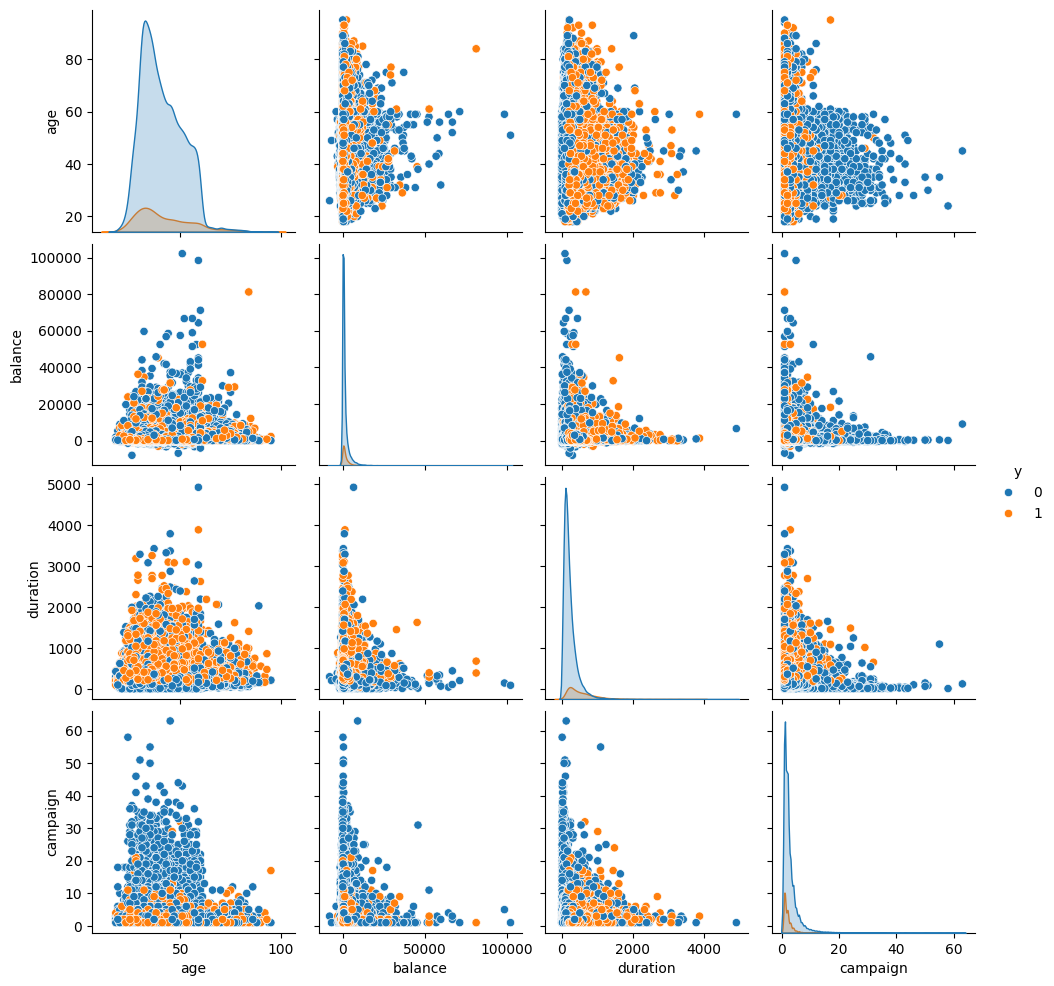

In [73]:
#Pairplot

sns.pairplot(
    df[['age','balance','duration','campaign','y']],
    hue='y'
)

plt.show()

In [74]:
#Business Summary

print("="*60)

print("BUSINESS INSIGHTS")

print("="*60)

print(f"Total Customers : {len(df)}")

print(f"Subscribed : {(df['y']==1).sum()}")

print(f"Not Subscribed : {(df['y']==0).sum()}")

print()

print("Top 5 Jobs")

print(df['job'].value_counts().head())

print()

print("Top Education")

print(df['education'].value_counts())

print()

print("Most Contact Month")

print(df['month'].value_counts().head())

print()

print("Average Age :", round(df['age'].mean(),2))

print("Average Balance :", round(df['balance'].mean(),2))

BUSINESS INSIGHTS
Total Customers : 45211
Subscribed : 5289
Not Subscribed : 39922

Top 5 Jobs
job
blue-collar    10020
management      9458
technician      7597
admin.          5171
services        4154
Name: count, dtype: int64

Top Education
education
secondary    25059
tertiary     13301
primary       6851
Name: count, dtype: int64

Most Contact Month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
Name: count, dtype: int64

Average Age : 40.94
Average Balance : 1362.27


In [75]:
#Decision Tree Classifier

#Train Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [76]:
# ==========================================
# Train Decision Tree Model
# ==========================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [77]:
#Predictions

y_pred = dt_model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [78]:
#Accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Accuracy Percentage : {accuracy*100:.2f}%")

Accuracy : 0.8656
Accuracy Percentage : 86.56%


In [79]:
#Model Evaluation

# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7985
           1       0.43      0.47      0.45      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.69      0.69      9043
weighted avg       0.87      0.87      0.87      9043



In [80]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[7335,  650],
       [ 565,  493]])

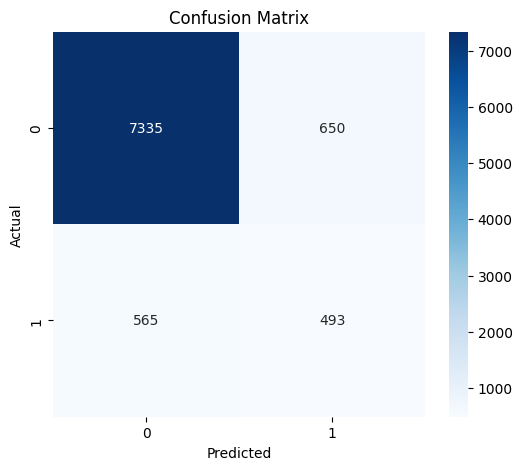

In [81]:
#Confusion Matrix Heatmap

# ==========================================
# Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [82]:


# ==========================================
# Precision Recall F1
# ==========================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Precision : 0.4313
Recall : 0.4660
F1 Score : 0.4480


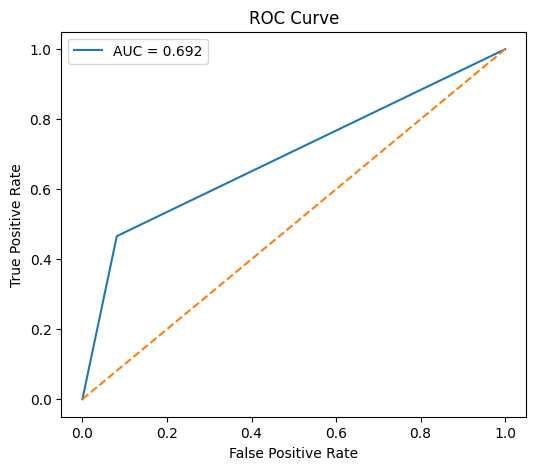

In [83]:
#ROC Curve

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

probability = dt_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(
    y_test,
    probability
)

auc = roc_auc_score(
    y_test,
    probability
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

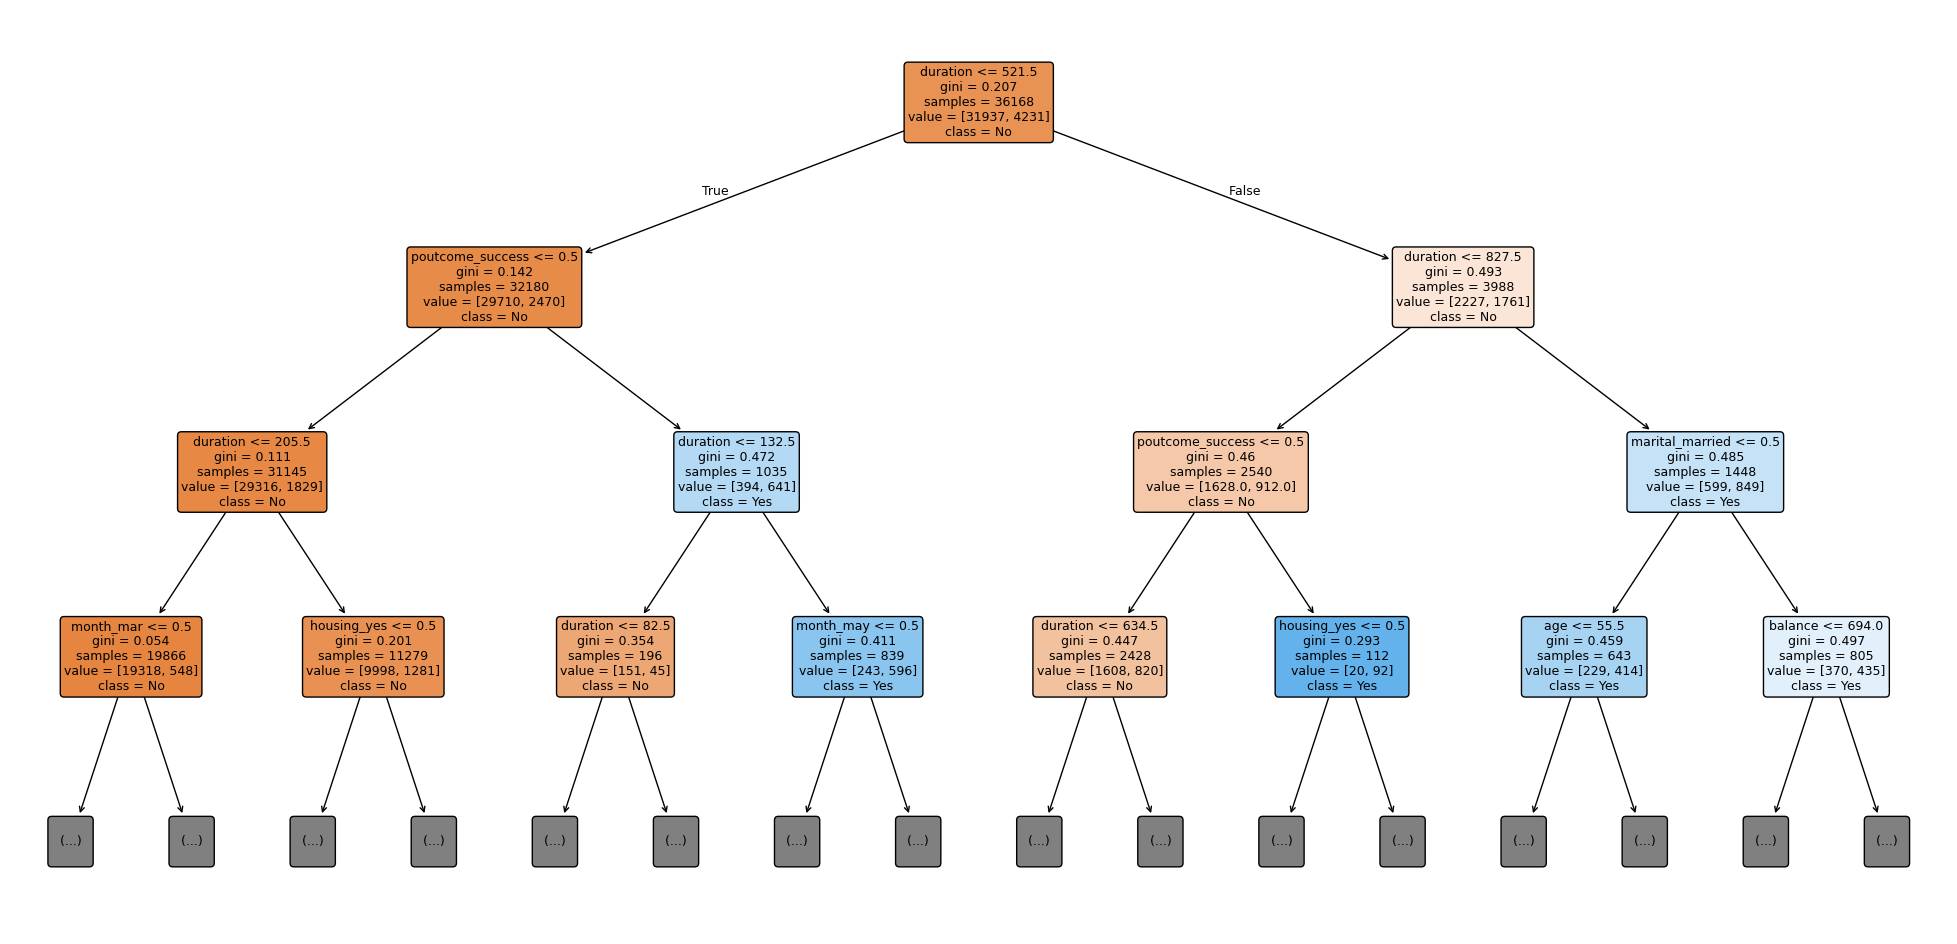

In [84]:
#Decision Tree Visualization

# ==========================================
# Decision Tree Visualization
# ==========================================

from sklearn.tree import plot_tree

plt.figure(figsize=(25,12))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.show()

In [85]:


# ==========================================
# Tree Information
# ==========================================

print("Tree Depth :", dt_model.get_depth())

print("Number of Leaves :", dt_model.get_n_leaves())

Tree Depth : 36
Number of Leaves : 3096


In [86]:
#Feature Importance

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":dt_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
3,duration,0.28
1,balance,0.12
0,age,0.10
37,poutcome_success,0.09
2,day,0.09
5,pdays,0.05
4,campaign,0.03
22,housing_yes,0.02
6,previous,0.02
31,month_mar,0.01


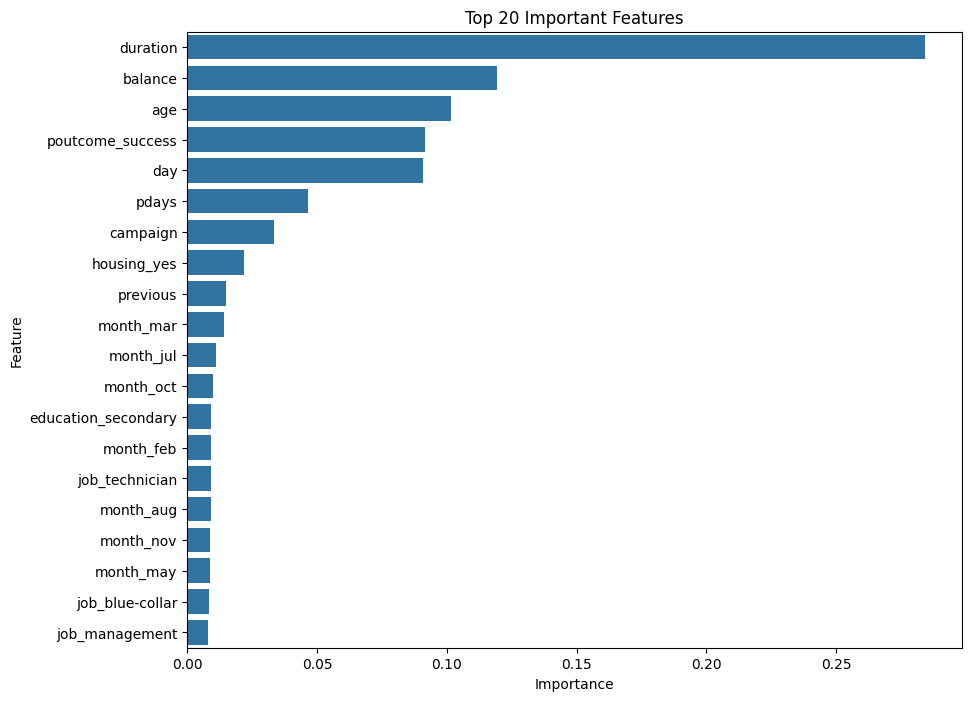

In [87]:
#Top 20 Important Features

# ==========================================
# Feature Importance Graph
# ==========================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [88]:
#Hyperparameter Tuning

#Grid Search

from sklearn.model_selection import GridSearchCV

parameters = {

    "criterion":["gini","entropy"],

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid = GridSearchCV(

    estimator=DecisionTreeClassifier(random_state=42),

    param_grid=parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [89]:
# ==========================================
# Best Decision Tree
# ==========================================

best_dt = grid.best_estimator_

best_dt

DecisionTreeClassifier(max_depth=5, random_state=42)

In [90]:
#Predict with Best Model

best_prediction = best_dt.predict(X_test)

accuracy = accuracy_score(

    y_test,

    best_prediction

)

print(f"Optimized Accuracy : {accuracy:.4f}")

Optimized Accuracy : 0.8996


In [91]:
#Classification Report

# ==========================================
# Final Classification Report
# ==========================================

print(

    classification_report(

        y_test,

        best_prediction

    )

)

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7985
           1       0.65      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



In [92]:
#Save Model

import joblib

joblib.dump(

    best_dt,

    "decision_tree.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [93]:
#Load Saved Model

loaded_model = joblib.load(

    "decision_tree.pkl"

)

loaded_model

DecisionTreeClassifier(max_depth=5, random_state=42)

In [94]:
#Predict Using Loaded Model

loaded_prediction = loaded_model.predict(

    X_test

)

accuracy_score(

    y_test,

    loaded_prediction

)

0.8995908437465443

In [95]:
#Final Summary

print("="*60)





print(f"Accuracy : {accuracy_score(y_test,best_prediction):.4f}")

print(f"Tree Depth : {best_dt.get_depth()}")

print(f"Leaf Nodes : {best_dt.get_n_leaves()}")

print("\nTop 10 Important Features:")

print(importance.head(10))

print("\nDecision Tree Model Built Successfully!")

print("Model Evaluated Successfully!")

print("Hyperparameter Tuning Completed!")

print("Model Saved Successfully!")

Accuracy : 0.8996
Tree Depth : 5
Leaf Nodes : 32

Top 10 Important Features:
             Feature  Importance
3           duration        0.28
1            balance        0.12
0                age        0.10
37  poutcome_success        0.09
2                day        0.09
5              pdays        0.05
4           campaign        0.03
22       housing_yes        0.02
6           previous        0.02
31         month_mar        0.01

Decision Tree Model Built Successfully!
Model Evaluated Successfully!
Hyperparameter Tuning Completed!
Model Saved Successfully!
